# **The Direct Method**

We start by graphing the polynomial function $f(x) = x^3 - 2x^2 + 4x - 8$. We use the domain D=[-5, 7], where the root x=2 is situated, using 400 points.

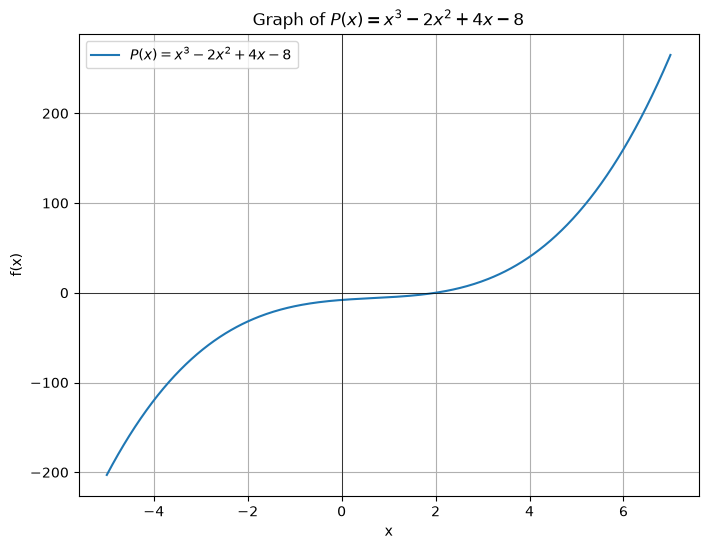

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate a range of x values
x = np.linspace(-5, 7, 400)
y = f(x)

# Create the plot
plt.figure(figsize=(8,6))
plt.plot(x, y, label=r'$P(x)=x^3 - 2x^2 + 4x - 8$')
plt.axhline(0, color='black', linewidth=0.5)  # x-axis
plt.axvline(0, color='black', linewidth=0.5)  # y-axis
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Graph of $P(x)=x^3 - 2x^2 + 4x - 8$')
plt.legend()
plt.grid(True)
plt.show()


The following is a Keras implementation using a 1-hiden layer neural network to find the solution of P(x) = 0. For training purposses a dummy traget has been used.

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the algebraic function
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Neural network model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(1)
])


# Custom loss function that depends only on the model output.
def custom_loss(y_true, y_pred):
    # y_true is a dummy target and is ignored.
    # The loss is the mean squared value of f(x_NN)
    return tf.reduce_mean(tf.square(f(y_pred)))

# Compile the model using the custom loss and an optimizer (Adam in this case)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)
model.compile(optimizer=optimizer, loss=custom_loss)

# Since our loss function doesn't require actual target values,
# we create dummy targets. We use the same dummy value for each sample.
t = 1.0 #this is the input to the NN. It can be any number.
dummy_input = np.array([[t]])
dummy_target = np.array([[0.0]])

# Train the model using model.fit; here, we only have one data point.
model.fit(dummy_input, dummy_target, epochs=300, verbose=2)

# Extract the solution by querying the network with the same dummy input
x_solution = model(tf.constant([[t]])).numpy()[0, 0]
print(f"Approximate solution: x = {x_solution}")

I0000 00:00:1782972946.299171   46709 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782972946.525316   46709 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782972953.708299   46709 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1782972954.646010   46709 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/300
1/1 - 3s - 3s/step - loss: 69.9950
Epoch 2/300
1/1 - 0s - 132ms/step - loss: 52.1602
Epoch 3/300
1/1 - 0s - 131ms/step - loss: 40.4249
Epoch 4/300
1/1 - 0s - 127ms/step - loss: 31.3938
Epoch 5/300
1/1 - 0s - 147ms/step - loss: 23.1190
Epoch 6/300
1/1 - 0s - 132ms/step - loss: 14.6981
Epoch 7/300
1/1 - 0s - 151ms/step - loss: 6.4279
Epoch 8/300
1/1 - 0s - 340ms/step - loss: 0.5952
Epoch 9/300
1/1 - 0s - 127ms/step - loss: 2.1581
Epoch 10/300
1/1 - 0s - 157ms/step - loss: 10.8553
Epoch 11/300
1/1 - 0s - 162ms/step - loss: 12.7094
Epoch 12/300
1/1 - 0s - 147ms/step - loss: 7.8483
Epoch 13/300
1/1 - 0s - 160ms/step - loss: 2.6756
Epoch 14/300
1/1 - 0s - 203ms/step - loss: 0.2194
Epoch 15/300
1/1 - 0s - 153ms/step - loss: 0.2549
Epoch 16/300
1/1 - 0s - 175ms/step - loss: 1.5144
Epoch 17/300
1/1 - 0s - 189ms/step - loss: 2.9774
Epoch 18/300
1/1 - 0s - 195ms/step - loss: 4.1047
Epoch 19/300
1/1 - 0s - 199ms/step - loss: 4.6921
Epoch 20/300
1/1 - 0s - 150ms/step - loss: 4.7131
Epoc

**Code variant**

The next code is a variant of implementation using tf.GradientTape() for computing gradients. We obtain again the solution $x^*=2$.

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the algebraic function
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Neural network
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Loss function: Mean squared value of f(x_NN)
def loss_fn():
    x = model(tf.constant([[1.0]]))  # Single input (scalar)
    return tf.reduce_mean(f(x)**2)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Training loop
for epoch in range(500):
    with tf.GradientTape() as tape:
        loss = loss_fn()
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Solution
x_solution = model(tf.constant([[1.0]])).numpy()[0, 0]
print(f"Approximate solution: x = {x_solution}")

Epoch 0, Loss: 126.57878875732422
Epoch 100, Loss: 0.006656489800661802
Epoch 200, Loss: 2.0262086763978004e-07
Epoch 300, Loss: 0.0
Epoch 400, Loss: 0.0
Approximate solution: x = 2.0


**Synthetic Division implementation**

Since c=2 is a root of f(x), then (x-2) is a factor of f(x), so f(x) = (x-2) g(x). The quotient g(x) can be found using synthetic division as follows:

In [5]:
def synthetic_division(coeffs, c):
    """
    Perform synthetic division of a polynomial by (x - c).

    Parameters:
        coeffs (list): Coefficients [a_n, a_(n-1), ..., a_0] of the polynomial P(x) = a_n*x^n + ... + a_0.
        c (float): The value for which (x - c) is the divisor.

    Returns:
        quotient (list): Coefficients of the quotient polynomial.
        remainder (float): The remainder of the division.
    """
    quotient = [coeffs[0]]
    for coef in coeffs[1:]:
        quotient.append(coef + c * quotient[-1])
    remainder = quotient.pop()  # Last element is the remainder
    return quotient, remainder

# Given polynomial P(x) = x^3 - 2*x^2 + 4*x - 8
coeffs = [1, -2, 4, -8]
# Dividing by (x - 2), so c = 2
c = 2

quotient, remainder = synthetic_division(coeffs, c)
print("Quotient coefficients:", quotient)
print("Remainder:", remainder)


Quotient coefficients: [1, 0, 4]
Remainder: 0


**Solving for complex solutions**

This indicates that $g(x) = x^2 +4$. We aim now to solve the equation
$=x^2+4=0$,
by representing a complex number in polar form. We use a neural network that accepts a fixed input \(t\) (dummy input) and produces a two-dimensional output
$
f_{\theta}(t)=(\rho_{\theta}(t),\, \varphi_{\theta}(t)).
$

We then interpret the network's output as the complex number
$
x_{\theta}=\rho_{\theta}\,e^{i\varphi_{\theta}}.
$
For the polynomial
$
g(x)=x^2+4,
$
the coefficients are $a_2=1$, $a_1=0$, and $a_0=4$.


 Based on the formulation, the loss function is defined as:
$
L(\theta)=a_0^2+2\,a_0\,a_2\,\rho^2\cos(2\varphi)+\rho^4,
$
which, with $a_0=4$ and $a_2=1$, becomes
$
L(\theta)=16+8\,\rho^2\cos(2\varphi)+\rho^4.
$

The goal is to minimize this loss with respect to the network parameters $\theta$. The code is given below:


In [6]:
import tensorflow as tf
import numpy as np

# Polynomial coefficients for P(x) = x^2 + 4 = 0
# Here, a2 = 1 and a0 = 4.
a2 = 1.0
a0 = 4.0

# Custom loss function:
# For a given output [rho, varphi], the loss is:
# L = a0^2 + 2*a0*a2*rho^2*cos(2*varphi) + rho^4.
# This loss drives the network to adjust its outputs so that the complex number
# x = rho * exp(i*varphi) becomes a root of the polynomial.
def custom_loss(y_true, y_pred):
    # Extract the two outputs: first is rho, second is varphi.
    rho = y_pred[:, 0]
    varphi = y_pred[:, 1]
    # Compute the loss as described.
    loss = a0**2 + 2 * a0 * a2 * tf.square(rho) * tf.cos(2 * varphi) + tf.pow(rho, 4)
    return tf.reduce_mean(loss)

# Build the neural network model.
# The model takes a dummy input (a scalar) and outputs a two-dimensional vector [rho, varphi].
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(2)  # Outputs: [rho, varphi]
])

# Compile the model with the custom loss and an Adam optimizer.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss=custom_loss)

# Since the loss depends solely on the network's output, we use a dummy input.
t = 1.0  # The input can be any fixed number.
dummy_input = np.array([[t]])
dummy_target = np.array([[0.0, 0.0]])  # Dummy target (not used in the loss)

# Train the model.
model.fit(dummy_input, dummy_target, epochs=500, verbose=2)

# Extract the outputs from the trained model.
output = model.predict(dummy_input)
rho = output[0, 0]
varphi = output[0, 1]
# Construct the approximate complex solution in polar form.
solution1 = rho * np.exp(1j * varphi)
print("Approximate complex solution:", solution1)
solution2 = rho * np.exp(-1j * varphi)
print("Approximate complex solution:", solution2)


Epoch 1/500
1/1 - 3s - 3s/step - loss: 16.0535
Epoch 2/500
1/1 - 0s - 191ms/step - loss: 15.9564
Epoch 3/500
1/1 - 0s - 203ms/step - loss: 15.8549
Epoch 4/500
1/1 - 0s - 194ms/step - loss: 15.5484
Epoch 5/500
1/1 - 0s - 174ms/step - loss: 14.9379
Epoch 6/500
1/1 - 0s - 346ms/step - loss: 13.9985
Epoch 7/500
1/1 - 0s - 201ms/step - loss: 12.7722
Epoch 8/500
1/1 - 0s - 186ms/step - loss: 11.3676
Epoch 9/500
1/1 - 0s - 257ms/step - loss: 9.8188
Epoch 10/500
1/1 - 0s - 169ms/step - loss: 8.0129
Epoch 11/500
1/1 - 0s - 138ms/step - loss: 5.9985
Epoch 12/500
1/1 - 0s - 137ms/step - loss: 3.9490
Epoch 13/500
1/1 - 0s - 154ms/step - loss: 2.1644
Epoch 14/500
1/1 - 0s - 296ms/step - loss: 0.9481
Epoch 15/500
1/1 - 0s - 145ms/step - loss: 0.2329
Epoch 16/500
1/1 - 0s - 143ms/step - loss: 0.1289
Epoch 17/500
1/1 - 0s - 158ms/step - loss: 0.9369
Epoch 18/500
1/1 - 0s - 150ms/step - loss: 1.8781
Epoch 19/500
1/1 - 0s - 127ms/step - loss: 2.3208
Epoch 20/500
1/1 - 0s - 130ms/step - loss: 2.4097
Epoc

We obtained two complex conjugate solutions, 2i and -2i. The real part is a zero machine number and it is discarded.

**The Supervised Inverse Construction**

In this construction we generate data and infer the inverse function $f^{-1}(y)$ from data. The graph of the inverse is provided.

Epoch 1/100


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.3205
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0703
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0164
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0070
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0072
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0061
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0047
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0028
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0021
E

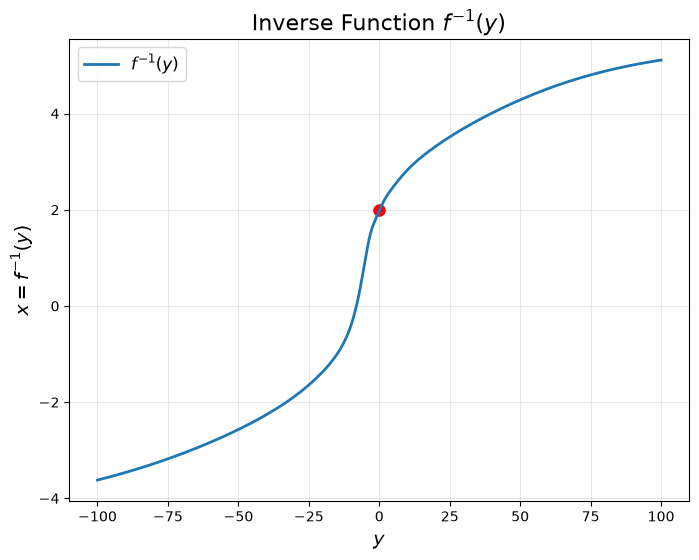

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Define the function f(x)
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate training data
x_train = np.linspace(-4, 5, 1000).reshape(-1, 1)  # Sample x values
y_train = f(x_train)  # Compute corresponding y values

# Build the neural network
model = Sequential([
    Input(shape=(1,)),
    Dense(80, activation='tanh'),  # Hidden layer with 80 neurons
    #Dense(100, activation='tanh'),  # Another hidden layer
    Dense(1)  # Output layer
])


# Compile the model with mean squared error loss
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train the model
model.fit(y_train, x_train, epochs=100, batch_size=32, verbose=1)

# Generate a range of y values for testing
y_vals = np.linspace(-100, 100, 1000).reshape(-1, 1)

# Use the trained model to predict the inverse function values (f^{-1}(y))
x_preds = model.predict(y_vals)

# Plot the inverse function
plt.figure(figsize=(8, 6))
plt.plot(0, 2, "ro", markersize=8)  # Plot the point (0,2) in red
plt.plot(y_vals, x_preds, label="$f^{-1}(y)$", linewidth=2)
plt.title("Inverse Function $f^{-1}(y)$", fontsize=16)
plt.xlabel("$y$", fontsize=14)
plt.ylabel("$x = f^{-1}(y)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


To solve the equation $f(x)=0$, using the inverse, we obtain $x=f^{-1}(0)$. From the graph we notice that $f^{-1}(0) =2$, since $(0,2)$ is a point on the graph of $f^{-1}$.

**The Unsupervised Inverse Construction**

This construction uses the functional equation $f(f^{-1}(y)) =y$ to find t

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 202.9742
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0599
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.5159
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5849
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2603
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1497
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1457
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5632
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8066
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6984
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4700
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2365
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4224
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9291
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - 

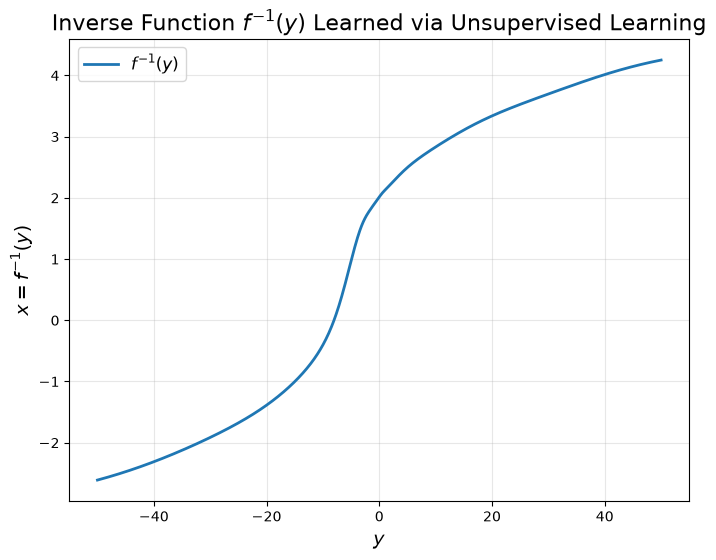

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the function f(x)
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate y values for training
y_train = np.linspace(-50, 50, 1000).reshape(-1, 1)  # Sample y values

# Build the neural network
model = Sequential([
    Input(shape=(1,)),
    Dense(50, activation='tanh'),  # Hidden layer with 50 neurons
    Dense(20, activation='tanh'),  # Another hidden layer
    Dense(1)  # Output layer
])

# Define the custom loss function
def unsupervised_loss(y_true, y_pred):
    # Compute f(NN(y)) - y
    return tf.reduce_mean(tf.square(f(y_pred) - y_true))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=unsupervised_loss)

# Train the model
model.fit(y_train, y_train, epochs=100, batch_size=32, verbose=1)  # Note: y_train is used as both input and target

# Generate y values for plotting the inverse function
y_vals = np.linspace(-50, 50, 1000).reshape(-1, 1)

# Predict x values using the trained model
x_preds = model.predict(y_vals)

# Plot the inverse function
plt.figure(figsize=(8, 6))
plt.plot(y_vals, x_preds, label="$f^{-1}(y)$", linewidth=2)
plt.title("Inverse Function $f^{-1}(y)$ Learned via Unsupervised Learning", fontsize=16)
plt.xlabel("$y$", fontsize=14)
plt.ylabel("$x = f^{-1}(y)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()